# Анализ и прогнозирование временных рядов методами искусственного интеллекта

## **Практическая работа 6. Поиск эволюционирующих шаблонов с помощью матричного профиля ряда.**

In [ ]:
%load_ext autoreload
%autoreload 2

## **Часть 1.** Поиск цепочек временного ряда.

Импорт библиотек и модулей

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import stumpy
from sklearn.metrics import mean_squared_error

In [2]:
from google.colab import drive
import os

drive.mount('/content/drive')
practice_dir_path = '/content/drive/MyDrive/2025-Murzin-TimeSeriesCourse-main/practice/06 Chains'
os.chdir(practice_dir_path)

Mounted at /content/drive


In [3]:
!pwd

/content/drive/MyDrive/2025-Murzin-TimeSeriesCourse-main/practice/06 Chains


В первом задании вам предстоит выполнить поиск эволюционирующих шаблонов временного ряда. Выполните считывание набора данных [Rotation Matrix](datasets/Rotation%20Matrix.txt), найдите в нем самую длинную цепочку и выведите индексы начала звеньев этой цепочки.

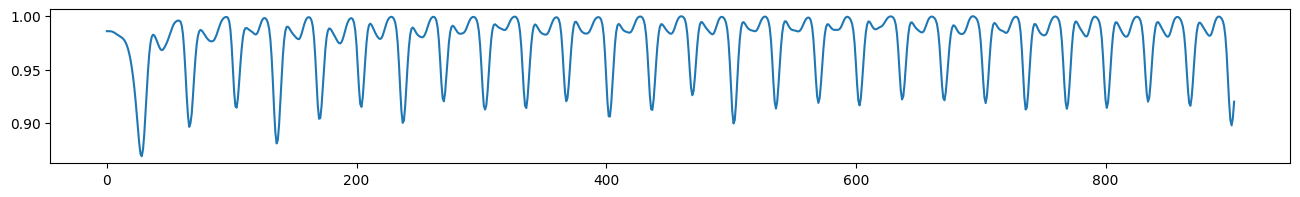

In [4]:
fig, ax = plt.subplots(figsize=(16, 2))
ts = np.loadtxt(f'{practice_dir_path}/datasets/Rotation Matrix.txt')
ax.plot(ts)

In [ ]:
# INSERT YOUR CODE

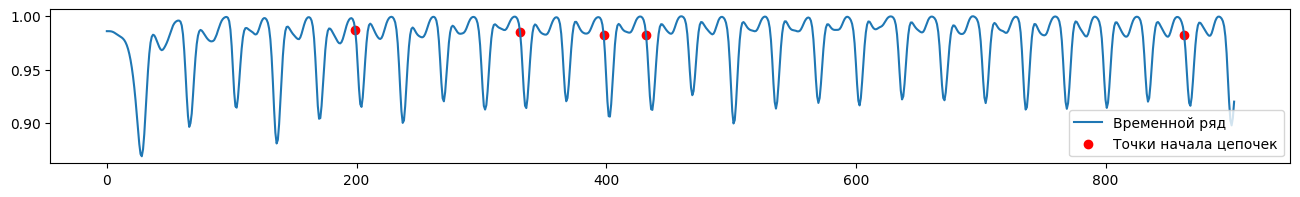

Индексы начала самой длинной цепочки: [199 331 398 432 863]


In [5]:
import numpy as np
import matplotlib.pyplot as plt
import stumpy

m = 25

matrix_profile = stumpy.stump(ts, m=m)
all_chain_set, chain_indices = stumpy.allc(matrix_profile[:,2], matrix_profile[:,3])

fig, ax = plt.subplots(figsize=(16, 2))
ax.plot(ts, label='Временной ряд')
ax.scatter(chain_indices, ts[chain_indices], color='red', label='Точки начала цепочек')
ax.legend()
plt.show()

print(f"Индексы начала самой длинной цепочки: {chain_indices}")


❓ Проанализируйте и изложите содержательный смысл полученных результатов.

Цепочка (или паттерн) - это устойчивая, повторяющаяся последовательность значений или движений в времянном ряду, которая имеет определенную форму и смысл.

Матричный профиль, вычисляемый алгоритмом STUMP - это вектор, где каждый элемент соответствукт минимальному расстоянию между подотрезком временного ряда длины m и его ближайшим соседом в том же ряду. Минимумы в этом профиле сигнализируют о повторяющихся паттернах, а максимумы - об аномалиях или уникальных участках.

На графике отмечено 5 точек с индексами 199, 331, 398, 432 и 863, которые являются началом звеньев цепочки. Тем самым, делается предположение, что имеется несколько повторяющихся паттернов.

## **Часть 2. Визуализация цепочек**

Выполните визуализацию найденных в прошлом задании цепочек: постройте график временного ряда, на котором выделены звенья цепочек. Также постройте график, на котором изображены только сами звенья.

In [ ]:
# INSERT YOUR CODE

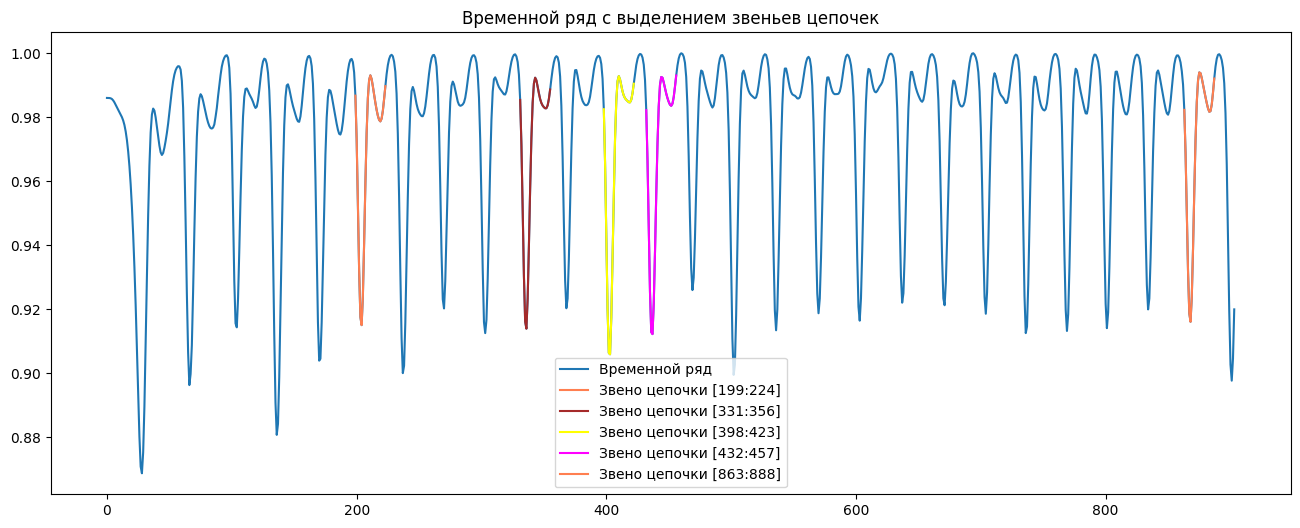

Индексы начала цепочек: [199 331 398 432 863]


In [6]:
import random
colors = ['coral', 'green', 'orange', 'brown', 'yellow', 'magenta']

fig, ax = plt.subplots(figsize=(16,6))
ax.plot(ts, label = 'Временной ряд')
for idx in chain_indices:
    ax.plot(range(idx, idx+m), ts[idx:idx+m], color=random.choice(colors), label=f'Звено цепочки [{idx}:{idx+m}]')
ax.legend()
plt.title('Временной ряд с выделением звеньев цепочек')
plt.show()

print(f"Индексы начала цепочек: {chain_indices}")

❓ Проанализируйте и изложите содержательный смысл полученных результатов.

Как представлено на графике, присутствует 5 звеньев цепочки, выделенные разными цветами.

Во временном ряду все звенья имеют одинаковую длину m = 25, таким образом алгоритм искал и находил один и тот же повторяющийся паттерн фиксированной длины в разных частях временного ряда.

## **Часть 3.** Предсказывание значений ряда на основе цепочек.

Предскажите значения последнего звена цепочки, вычислив разность между двумя предыдущими звеньями цепочки. Сравните полученное предсказание с истинным значением.

In [ ]:
# INSERT YOUR CODE

In [14]:
last_two_indeces = chain_indices[-2:]
last_two_segments = [ts[idx:idx+m] for idx in last_two_indeces]
diff = last_two_segments[1] - last_two_segments[0]
predicted_last_segment = last_two_segments[1] + diff
true_last_segment = ts[chain_indices[-1]:chain_indices[-1] + m]

print(f'\n{predicted_last_segment}')
print(f'\n{true_last_segment}')


[0.98236196 0.97123377 0.95548284 0.93792801 0.92448315 0.9198852
 0.9259537  0.94000704 0.95779585 0.9739958  0.98597246 0.9928255
 0.99539054 0.9951612  0.9935063  0.99130279 0.9889372  0.98648324
 0.9839618  0.9815725  0.9798049  0.9795438  0.98162394 0.9859888
 0.9911284 ]

[0.9822649  0.9688284  0.9504531  0.93155193 0.9186431  0.9160235
 0.9238268  0.9388921  0.9567697  0.9728658  0.9846746  0.991442
 0.993967   0.99374235 0.9921726  0.99017346 0.9881557  0.9862134
 0.9843672  0.98273253 0.9816686  0.981872   0.98394907 0.987732
 0.992072  ]


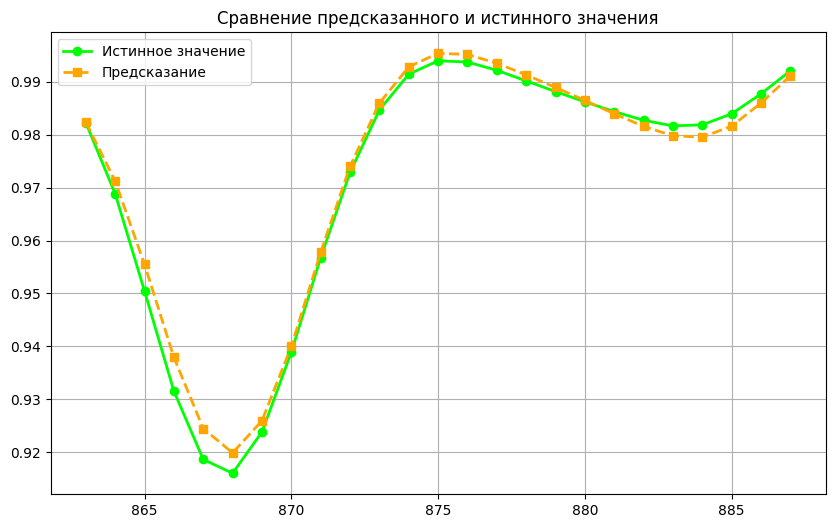

In [23]:
plt.figure(figsize=(10,6))
plt.plot(range(last_two_indeces[1], last_two_indeces[1]+m), true_last_segment, 'o-', label='Истинное значение', color='lime', linewidth=2)
plt.plot(range(last_two_indeces[1], last_two_indeces[1]+m), predicted_last_segment, 's--', label='Предсказание', color='orange', linewidth=2)
plt.title('Сравнение предсказанного и истинного значения')
plt.legend()
plt.grid(True)
plt.show()

In [25]:
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error

true_segment = np.array(true_last_segment)
pred_segment = np.array(predicted_last_segment)

# Средняя абсолютная ошибка (MAE)
mae = mean_absolute_error(true_segment, pred_segment)
print(f"Средняя абсолютная ошибка (MAE): {mae:.4f}")

# Среднеквадратичная ошибка (MSE) - сильнее штрафует за большие ошибки
mse = mean_squared_error(true_segment, pred_segment)
print(f"Среднеквадратичная ошибка (MSE): {mse:.4f}")

# Корень из среднеквадратичной ошибки (RMSE) - в той же размерности, что и данные
rmse = np.sqrt(mse)
print(f"Корень из среднеквадратичной ошибки (RMSE): {rmse:.4f}")

# Коэффициент детерминации (R^2)
ss_res = np.sum((true_segment - pred_segment) ** 2)
ss_tot = np.sum((true_segment - np.mean(true_segment)) ** 2)
r2 = 1 - (ss_res / ss_tot) if ss_tot != 0 else 0
print(f"Коэффициент детерминации (R^2): {r2:.4f}")

Средняя абсолютная ошибка (MAE): 0.0020
Среднеквадратичная ошибка (MSE): 0.0000
Корень из среднеквадратичной ошибки (RMSE): 0.0025
Коэффициент детерминации (R^2): 0.9899


❓ Проанализируйте и изложите содержательный смысл полученных результатов.

На графике видно, что предсказанное значение очень близко к истинному значению. Это означает, что вычисления последнего звена цепочки через разность между предыдущими звеньями цепочки возможны и показывают высокую точность.


Также это подтверждается через вычисленные метрики MAE, MSE, RMSE и R^2.